# Seattle Collision Severity Regression

## tl;dr

The notebook predicts a continuous grid-cell severity score using five tuned regressors. Training-only repeated cross-validation selected **stabilized severity** over raw mean severity (mean R² 0.215 vs. 0.210, with lower fold-to-fold variation). **LightGBM** ranked first by training cross-validation R² (0.224) and achieved test R² 0.241, MAE 0.073, and RMSE 0.107. CatBoost was close behind with CV R² 0.222 and test R² 0.238. No selected feature directly contains severity, injuries, fatalities, collision count, or the former risk target.

## Context & Methods

The modeling unit is an occupied spatial grid cell. The target is collision severity aggregated within each cell. Candidate regressors follow the original notebook's progression: a decision tree, a random forest, XGBoost, LightGBM, and CatBoost.

### Key Assumptions

- Rows from the partial 2026 calendar year are excluded so every included year is complete.
- This is a historical, cell-level severity model. It does not claim to forecast a future year.
- Target-derived columns are explicitly excluded from the feature matrix.
- The stabilized target's global severity prior is calculated from the training partition only.
- Cross-validation selects the target and model; the test partition is used only for final evaluation.

## Data

### 1. Import libraries

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np

from scipy.stats import randint, loguniform, uniform
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    RepeatedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

### 2. Load the processed collision data

In [2]:
data_path = Path('../data/processed/Collision_Processed.parquet')
model_end_year = 2025

gdf = gpd.read_parquet(data_path)
gdf = gdf[gdf['YEAR'] <= model_end_year].copy()

print(f'Using {len(gdf):,} collision records through {model_end_year}.')
gdf.head()

Using 103,861 collision records through 2025.


,INCKEY,COLDETKEY,REPORTNO,LOCATION,MAXSEVERITYCODE,MAXSEVERITYDESC,PERSONCOUNT,PEDCOUNT,PEDCYLCOUNT,VEHCOUNT,...,Season,GEOMETRY_STATUS,HAS_VALID_GEOMETRY,X,Y,SEVERITY,TOTAL_PED,lat_bin,lon_bin,geometry
0,384696,386236,EF67714,IRONDALE AVE W AND W BERTONA ST,1,Property Damage Only Collision,5,0,0,3,...,Winter,valid,True,-122.365545,47.650458,0,0,"(47.65, 47.652]","(-122.366, -122.364]",POINT (-122.36555 47.65046)
1,382571,384091,3931753,1ST AVE S BETWEEN S FIDALGO ST AND EAST MARGIN...,2,Injury Collision,2,0,0,2,...,Spring,valid,True,-122.334212,47.549380,1,0,"(47.548, 47.55]","(-122.335, -122.333]",POINT (-122.33421 47.54938)
2,382297,383817,EF97031,47TH AVE NE BETWEEN NE 70TH W ST AND NE 71ST ST,1,Property Damage Only Collision,0,0,0,0,...,Spring,valid,True,-122.278475,47.679724,0,0,"(47.679, 47.68]","(-122.279, -122.277]",POINT (-122.27848 47.67972)
3,382328,383848,EF97000,4TH AVE S AND S JACKSON ST,1,Property Damage Only Collision,2,0,0,2,...,Spring,valid,True,-122.328968,47.599197,0,0,"(47.599, 47.601]","(-122.33, -122.328]",POINT (-122.32897 47.5992)
4,382682,384202,EF99053,BEACON ER AVE S BETWEEN S EDDY ST AND S MORGAN ST,1,Property Damage Only Collision,0,0,0,0,...,Summer,valid,True,-122.299918,47.545014,0,0,"(47.543, 47.545]","(-122.301, -122.3]",POINT (-122.29992 47.54501)


### 3. Aggregate collisions into spatial grid cells

In [3]:
grid = gdf.groupby(['lat_bin', 'lon_bin']).agg(
    collision_count=('COLDETKEY', 'count'),
    severity_sum=('SEVERITY', 'sum'),
    mean_severity=('SEVERITY', 'mean'),
    mean_injuries=('INJURIES', 'mean'),
    mean_serious=('SERIOUSINJURIES', 'mean'),
    mean_fatalities=('FATALITIES', 'mean'),
    avg_vehicle_count=('VEHCOUNT', 'mean'),
    avg_pedestrian_count=('TOTAL_PED', 'mean'),
    cell_lat=('Y', 'mean'),
    cell_lon=('X', 'mean'),
    peak_hour=('HOUR', lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan),
    night_ratio=('HOUR', lambda x: ((x < 6) | (x >= 20)).mean()),
    weekend_ratio=('Day_of_Week', lambda x: x.isin(['Saturday', 'Sunday']).mean()),
    winter_ratio=('Season', lambda x: (x == 'Winter').mean()),
    summer_ratio=('Season', lambda x: (x == 'Summer').mean()),
    intersection_ratio=(
        'JUNCTIONTYPE',
        lambda x: x.str.contains('At Intersection', case=False, na=False).mean(),
    ),
).reset_index()

print(f'Created {len(grid):,} occupied grid cells.')
grid[['collision_count', 'severity_sum', 'mean_severity']].describe()

Created 8,364 occupied grid cells.


,collision_count,severity_sum,mean_severity
count,8364.000000,8364.000000,8364.000000
mean,12.417623,5.094931,0.311127
std,19.802161,10.055737,0.417926
min,1.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000
50%,5.000000,1.000000,0.200000
75%,14.000000,5.000000,0.500000
max,218.000000,109.000000,4.333333


## Target Engineering

### 4. Create raw and stabilized severity targets

`mean_severity` can be unstable in cells with only a few collisions. The alternative target shrinks each cell toward the training population's global severity rate. The global prior is calculated after the split and never uses held-out outcomes.

In [4]:
train_idx, test_idx = train_test_split(
    grid.index,
    test_size=0.2,
    random_state=42,
)

m = 10
global_severity = (
    grid.loc[train_idx, 'severity_sum'].sum()
    / grid.loc[train_idx, 'collision_count'].sum()
)

grid['severity_smoothed'] = (
    grid['severity_sum'] + m * global_severity
) / (grid['collision_count'] + m)

print(f'Training-only global severity prior: {global_severity:.4f}')
grid[['mean_severity', 'severity_smoothed']].describe()

Training-only global severity prior: 0.4101


,mean_severity,severity_smoothed
count,8364.000000,8364.000000
mean,0.311127,0.393358
std,0.417926,0.125582
min,0.000000,0.117171
25%,0.000000,0.315460
50%,0.200000,0.372816
75%,0.500000,0.435784
max,4.333333,1.373735


<Axes: >

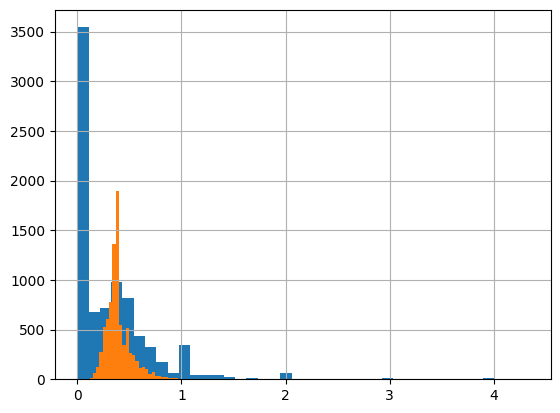

In [5]:
grid['mean_severity'].hist(bins=40)
grid['severity_smoothed'].hist(bins=40)

## Leakage-Safe Features

### 5. Document and validate the predictors

The features below do not contain `SEVERITY`, injuries, serious injuries, fatalities, collision count, severity aggregates, the old risk score, or the old risk label. The imputer is fitted inside each cross-validation fold through a pipeline.

`avg_vehicle_count` and `avg_pedestrian_count` are historical involvement summaries, not components of the severity formula. They are appropriate for this historical model, but a future forecasting model must compute them only from a prior lookback period.

In [6]:
features = [
    'cell_lat',
    'cell_lon',
    'peak_hour',
    'night_ratio',
    'weekend_ratio',
    'winter_ratio',
    'summer_ratio',
    'avg_vehicle_count',
    'avg_pedestrian_count',
    'intersection_ratio',
]

In [7]:
X_train = grid.loc[train_idx, features]
X_test = grid.loc[test_idx, features]

print(f'Training cells: {len(X_train):,}')
print(f'Test cells: {len(X_test):,}')
print(f'Constant selected features: {X_train.columns[X_train.nunique() <= 1].tolist()}')

Training cells: 6,691
Test cells: 1,673
Constant selected features: []


### 6. Select the severity target with training-only cross-validation

R² is used for target selection because the raw and stabilized targets have different scales. Repeated folds reduce the chance of selecting a target based on one unusually favorable split. The held-out test set is not consulted here.

In [8]:
target_cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

target_baseline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=14,
        min_samples_leaf=5,
        max_features=0.7,
        n_jobs=1,
        random_state=42,
    )),
])

target_results = []
for target_name in ['mean_severity', 'severity_smoothed']:
    scores = cross_val_score(
        target_baseline,
        X_train,
        grid.loc[train_idx, target_name],
        cv=target_cv,
        scoring='r2',
        n_jobs=-1,
    )
    target_results.append({
        'target': target_name,
        'mean_cv_r2': scores.mean(),
        'std_cv_r2': scores.std(),
    })

target_comparison = (
    pd.DataFrame(target_results)
    .sort_values('mean_cv_r2', ascending=False)
    .reset_index(drop=True)
)
selected_target = target_comparison.loc[0, 'target']

print(f'Selected target: {selected_target}')
target_comparison

Selected target: severity_smoothed


,target,mean_cv_r2,std_cv_r2
0,severity_smoothed,0.215433,0.029394
1,mean_severity,0.210355,0.040891


## Results

### 7. Define regression evaluation

Models are ranked by cross-validated training R². Test R², MAE, and RMSE are reported once for each fitted model as diagnostics. The selected production candidate is chosen from cross-validation rather than test performance.

In [9]:
y_train = grid.loc[train_idx, selected_target]
y_test = grid.loc[test_idx, selected_target]

model_cv = KFold(n_splits=5, shuffle=True, random_state=42)
model_results = []
fitted_models = {}
test_predictions = {}


def evaluate_regressor(model_name, search):
    best_model = search.best_estimator_
    y_pred = best_model.predict(X_test)

    result = {
        'model': model_name,
        'cv_r2': search.best_score_,
        'test_r2': r2_score(y_test, y_pred),
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': mean_squared_error(y_test, y_pred) ** 0.5,
    }
    model_results.append(result)
    fitted_models[model_name] = best_model
    test_predictions[model_name] = y_pred

    print('Best parameters:', search.best_params_)
    print('Cross-validation R²:', np.round(result['cv_r2'], 3))
    print('Test R²:', np.round(result['test_r2'], 3))
    print('Test MAE:', np.round(result['mae'], 3))
    print('Test RMSE:', np.round(result['rmse'], 3))

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].scatter(y_test, y_pred, alpha=0.35, s=18)
    bounds = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
    axes[0].plot(bounds, bounds, linestyle='--', color='black')
    axes[0].set_title(f'{model_name}: Actual vs Predicted')
    axes[0].set_xlabel('Actual severity score')
    axes[0].set_ylabel('Predicted severity score')

    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=30, edgecolor='black')
    axes[1].axvline(0, linestyle='--', color='black')
    axes[1].set_title(f'{model_name}: Residual Distribution')
    axes[1].set_xlabel('Actual - predicted severity')
    axes[1].set_ylabel('Grid cells')

    plt.tight_layout()
    plt.show()

    fitted_regressor = best_model.named_steps['model']
    if hasattr(fitted_regressor, 'feature_importances_'):
        feature_importance = pd.Series(
            fitted_regressor.feature_importances_,
            index=features,
        ).sort_values(ascending=True)
        feature_importance.plot(kind='barh')
        plt.title(f'{model_name}: Feature Importance')
        plt.xlabel('Importance')
        plt.show()

    return best_model

### 8. Tune a Decision Tree Regressor

Best parameters: {'model__ccp_alpha': 0.0, 'model__criterion': 'squared_error', 'model__max_depth': 4, 'model__min_samples_leaf': 20, 'model__min_samples_split': 2}
Cross-validation R²: 0.143
Test R²: 0.158
Test MAE: 0.079
Test RMSE: 0.113


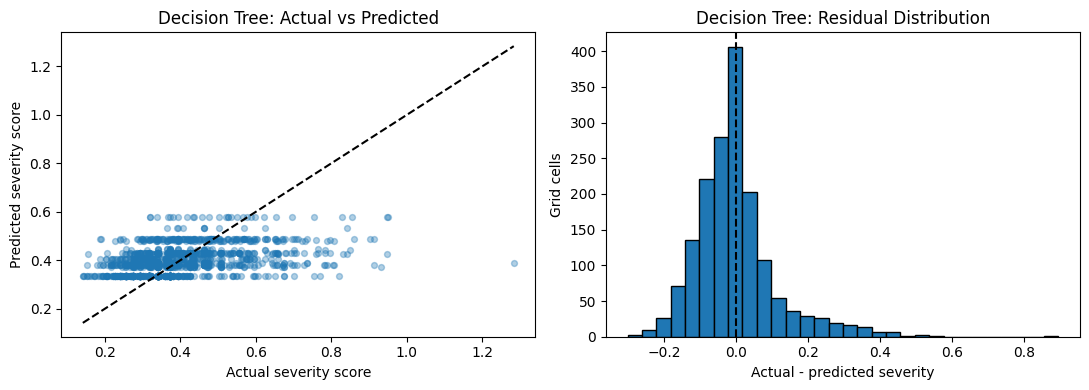

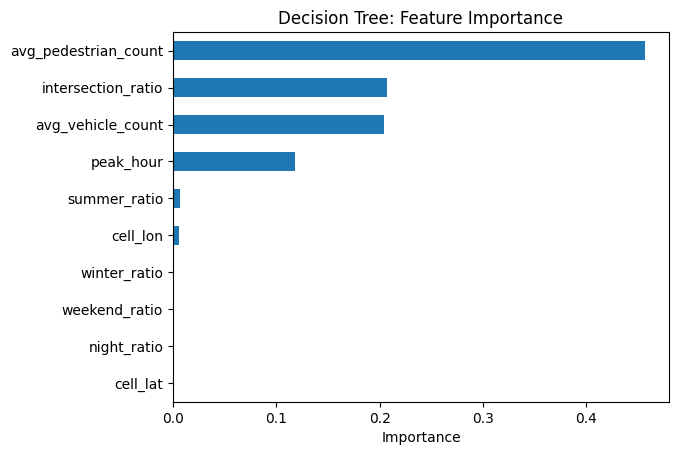

In [10]:
decision_tree_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', DecisionTreeRegressor(random_state=42)),
])

param_grid = {
    'model__max_depth': [4, 6, 8, 10, None],
    'model__min_samples_split': [2, 10, 20],
    'model__min_samples_leaf': [1, 5, 10, 20],
    'model__criterion': ['squared_error', 'friedman_mse'],
    'model__ccp_alpha': [0.0, 0.0001, 0.001],
}

grid_search = GridSearchCV(
    decision_tree_pipeline,
    param_grid,
    cv=model_cv,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True,
)
grid_search.fit(X_train, y_train)

decision_tree_model = evaluate_regressor('Decision Tree', grid_search)

### 9. Tune a Random Forest Regressor

Best parameters: {'model__n_estimators': 600, 'model__min_samples_split': 20, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 16, 'model__bootstrap': True}
Cross-validation R²: 0.222
Test R²: 0.237
Test MAE: 0.073
Test RMSE: 0.108


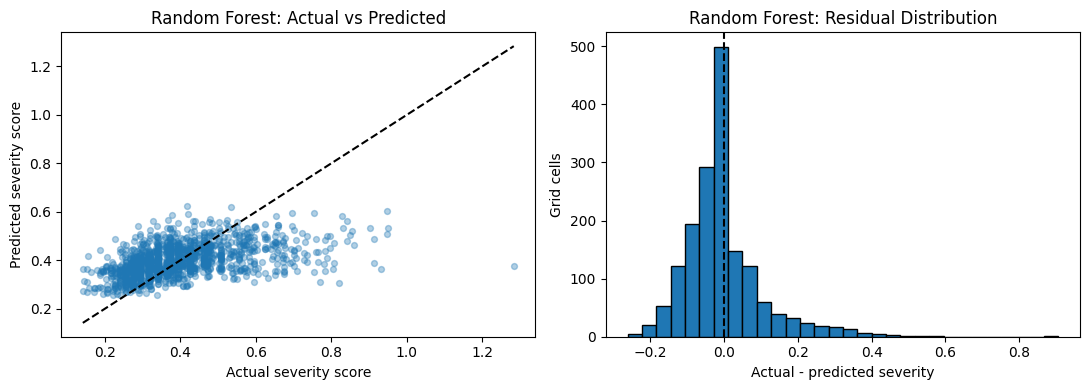

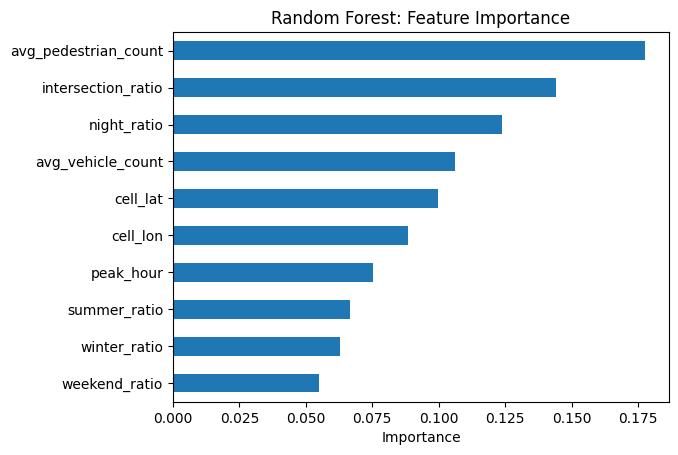

In [11]:
random_forest_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', RandomForestRegressor(random_state=42, n_jobs=1)),
])

param_distributions = {
    'model__n_estimators': [200, 300, 400, 600, 800],
    'model__max_features': ['sqrt', 'log2', 0.5, 0.8],
    'model__max_depth': [None, 8, 12, 16, 24],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8, 12],
    'model__bootstrap': [True, False],
}

random_forest_search = RandomizedSearchCV(
    random_forest_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=model_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
)
random_forest_search.fit(X_train, y_train)

random_forest_model = evaluate_regressor('Random Forest', random_forest_search)

### 10. Tune an XGBoost Regressor

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'model__colsample_bytree': np.float64(0.7564847850358383), 'model__gamma': np.float64(0.012561043700013555), 'model__learning_rate': np.float64(0.032211189352044464), 'model__max_depth': 2, 'model__min_child_weight': np.float64(5.958758776628972), 'model__n_estimators': 710, 'model__reg_alpha': np.float64(0.0004982752357076451), 'model__reg_lambda': np.float64(0.7523742884534856), 'model__subsample': np.float64(0.7782266451527922)}
Cross-validation R²: 0.215
Test R²: 0.23
Test MAE: 0.074
Test RMSE: 0.108


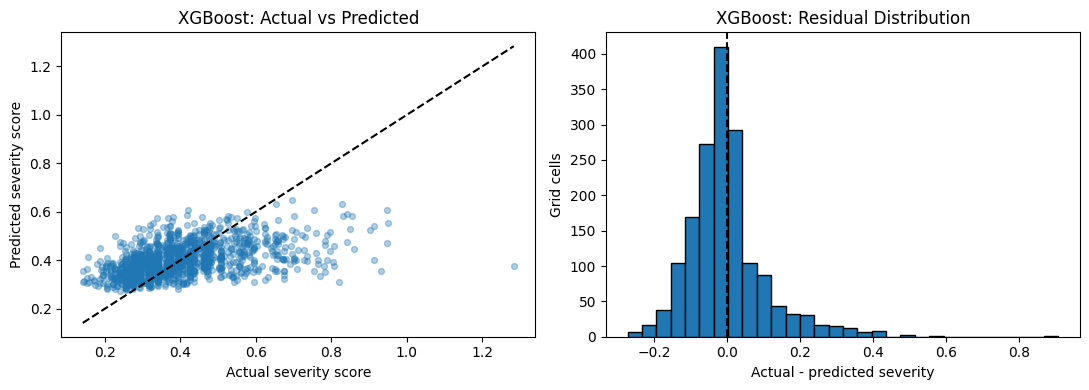

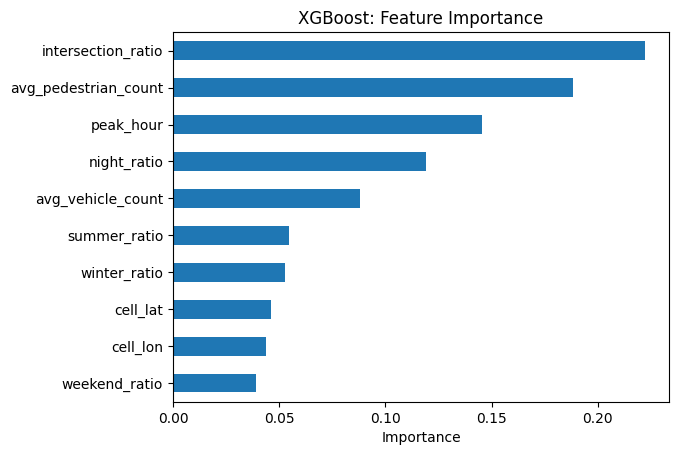

In [12]:
xgboost_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        eval_metric='rmse',
        tree_method='hist',
        n_jobs=1,
        random_state=42,
    )),
])

param_distributions = {
    'model__n_estimators': randint(200, 801),
    'model__max_depth': randint(2, 7),
    'model__learning_rate': loguniform(0.01, 0.15),
    'model__min_child_weight': loguniform(1, 30),
    'model__gamma': loguniform(1e-4, 1),
    'model__subsample': uniform(0.65, 0.35),
    'model__colsample_bytree': uniform(0.65, 0.35),
    'model__reg_alpha': loguniform(1e-4, 10),
    'model__reg_lambda': loguniform(0.1, 100),
}

xgboost_search = RandomizedSearchCV(
    xgboost_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=model_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
xgboost_search.fit(X_train, y_train)

xgboost_model = evaluate_regressor('XGBoost', xgboost_search)

### 11. Tune a LightGBM Regressor

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best parameters: {'model__colsample_bytree': np.float64(0.7496941730321137), 'model__learning_rate': np.float64(0.011050512402941122), 'model__max_depth': -1, 'model__min_child_samples': 11, 'model__n_estimators': 419, 'model__num_leaves': 37, 'model__reg_alpha': np.float64(0.002473046721099914), 'model__reg_lambda': np.float64(53.063715752208445), 'model__subsample': np.float64(0.7338466617334404)}
Cross-validation R²: 0.224
Test R²: 0.241
Test MAE: 0.073
Test RMSE: 0.107


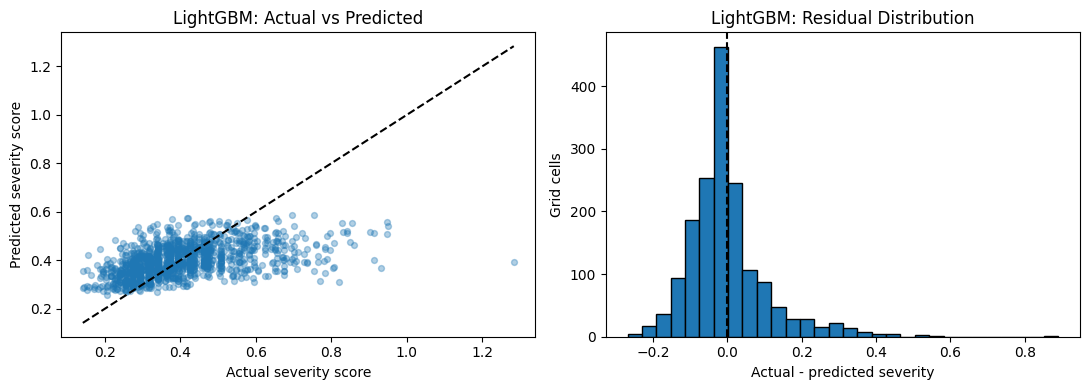

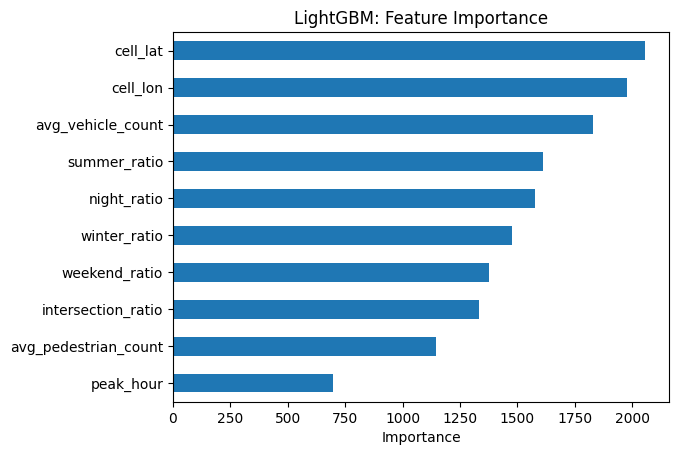

In [17]:
lightgbm_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', LGBMRegressor(
        objective='regression',
        subsample_freq=1,
        verbosity=-1,
        n_jobs=1,
        random_state=42,
    )),
])

param_distributions = {
    'model__n_estimators': randint(200, 801),
    'model__learning_rate': loguniform(0.01, 0.15),
    'model__num_leaves': randint(15, 64),
    'model__max_depth': [-1, 3, 4, 5, 6, 8],
    'model__min_child_samples': randint(10, 81),
    'model__subsample': uniform(0.65, 0.35),
    'model__colsample_bytree': uniform(0.65, 0.35),
    'model__reg_alpha': loguniform(1e-4, 10),
    'model__reg_lambda': loguniform(0.1, 100),
}

lightgbm_search = RandomizedSearchCV(
    lightgbm_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=model_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
lightgbm_search.fit(X_train, y_train)

lightgbm_model = evaluate_regressor('LightGBM', lightgbm_search)

### 12. Tune a CatBoost Regressor

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best parameters: {'model__bagging_temperature': np.float64(0.6099966577826209), 'model__depth': 6, 'model__iterations': 505, 'model__l2_leaf_reg': np.float64(3.7813243845450337), 'model__learning_rate': np.float64(0.01638046665239941), 'model__random_strength': np.float64(0.4231391553569692)}
Cross-validation R²: 0.222
Test R²: 0.238
Test MAE: 0.073
Test RMSE: 0.108


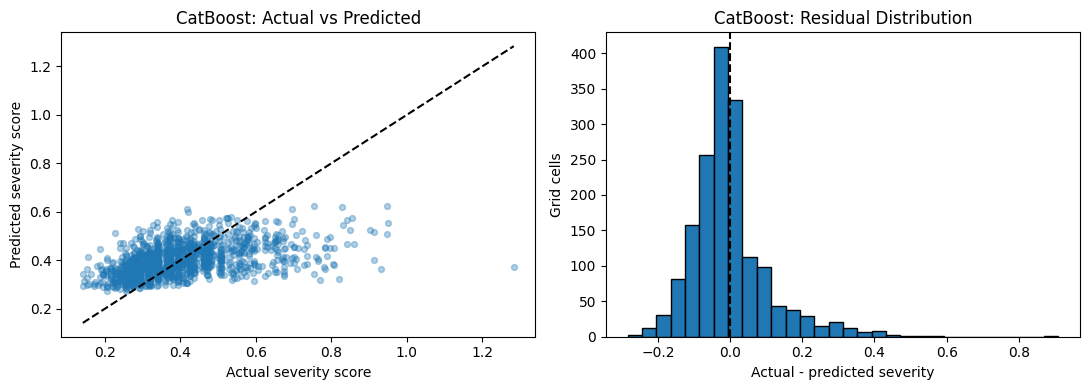

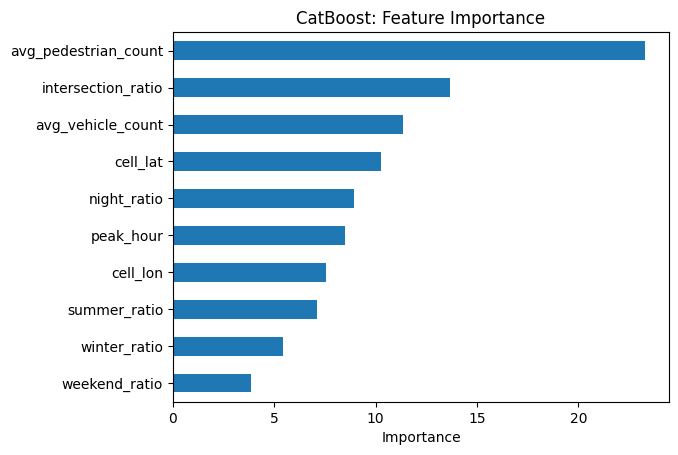

In [ ]:
catboost_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('model', CatBoostRegressor(
        loss_function='RMSE',
        verbose=0,
        allow_writing_files=False,
        thread_count=1,
        random_seed=42,
    )),
])

param_distributions = {
    'model__iterations': randint(300, 1001),
    'model__depth': randint(4, 9),
    'model__learning_rate': loguniform(0.01, 0.15),
    'model__l2_leaf_reg': loguniform(1, 30),
    'model__random_strength': loguniform(1e-3, 3),
    'model__bagging_temperature': uniform(0, 1),
}

catboost_search = RandomizedSearchCV(
    catboost_pipeline,
    param_distributions=param_distributions,
    n_iter=25,
    cv=model_cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    return_train_score=True,
    verbose=1,
)
catboost_search.fit(X_train, y_train)

catboost_model = evaluate_regressor('CatBoost', catboost_search)

### 13. Compare models without selecting on the test set

In [ ]:
model_comparison = (
    pd.DataFrame(model_results)
    .sort_values('cv_r2', ascending=False)
    .reset_index(drop=True)
)
selected_model_name = model_comparison.loc[0, 'model']
selected_model = fitted_models[selected_model_name]

print(f'Selected model from cross-validation: {selected_model_name}')
model_comparison

Selected model from cross-validation: LightGBM


,model,cv_r2,test_r2,mae,rmse
0,LightGBM,0.224260,0.240745,0.072640,0.107481
1,CatBoost,0.222146,0.237965,0.073438,0.107678
2,Random Forest,0.221921,0.237126,0.073278,0.107737
3,XGBoost,0.215483,0.229846,0.074248,0.108250
4,Decision Tree,0.142898,0.157738,0.079327,0.113204


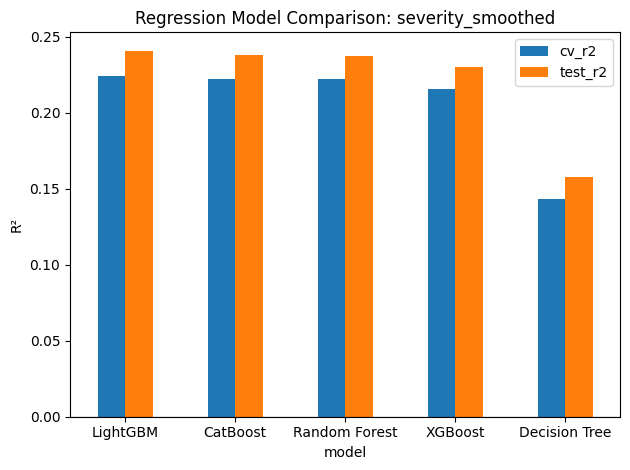

In [ ]:
model_comparison.set_index('model')[['cv_r2', 'test_r2']].plot(kind='bar')
plt.title(f'Regression Model Comparison: {selected_target}')
plt.ylabel('R²')
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## Takeaways

- Stabilized severity was retained because it produced slightly higher repeated cross-validation R² and lower fold-to-fold variation than raw mean severity.
- LightGBM was selected from training cross-validation, with CV R² 0.224 and held-out test R² 0.241.
- CatBoost performed similarly, with CV R² 0.222 and held-out test R² 0.238.
- The small differences among LightGBM, CatBoost, and Random Forest indicate that the feature set, rather than estimator choice, is the main performance constraint.
- Direct severity components and the former risk label are excluded from the predictors and enforced with an assertion.